# Aula 10 — Sistemas Lineares no Plano

**MA1049 — Introdução às Equações Diferenciais Ordinárias**  
**Prof. César Castilho — UFPE**

Nesta aula iniciaremos o estudo sistemático de sistemas lineares planares. A bibliografia utilizada:

- **Strogatz:** Capítulo 5;
- **Logemann & Ryan:** Capítulo 2.
- **Brian Bradie:** Capítulo 3.



> **Como a álgebra da matriz $A$ determina a geometria das soluções de**
>
> $$\dot{\mathbf{x}}=A\mathbf{x} ?$$


# Parte I — Plano de Fase

## 1. Sistemas

Considere uma equação de segunda ordem

$$
y''=F(t,y,y').
$$

Definindo

$$
x_1=y,\qquad x_2=y',
$$

obtemos

$$
\boxed{
\begin{cases}
x_1'=x_2,\\
x_2'=F(t,x_1,x_2).
\end{cases}}
$$

ou, em notação vetorial,

$$
\boxed{\mathbf{x}'=\mathbf{F}(t,\mathbf{x}).}
$$

A variável vetorial

$$
\mathbf{x}(t)=
\begin{pmatrix}
x_1(t)\\
x_2(t)
\end{pmatrix}
$$

é chamada de **estado** do sistema.


## 2. Exemplo fundamental — o oscilador harmônico

Considere uma massa $m$ presa a uma mola de constante elástica $k$:

$$
m x''+kx=0.
$$

Defina a velocidade

$$
v=x'.
$$

Então

$$
\boxed{
\begin{cases}
x'=v,\\
v'=-\omega^2x,
\end{cases}}
\qquad
\omega^2=\frac{k}{m}.
$$

Observe que como $k$ e $m$ são constantes positivas podemos
definir a razão entre estas grandezas como um número positivo $w^2$.
O estado é agora

$$
(x,v)\in\mathbb R^2.
$$

Em cada ponto $(x,v)$, o sistema associa o vetor

$$
(x',v')=(v,-\omega^2x).
$$

Portanto, a própria EDO define um **campo vetorial no plano**.

Antes de resolver o sistema, vamos tentar entender este campo.

### 2.1 Leitura do campo vetorial

No eixo $x$, temos $v=0$. Logo,

$$
(x',v')=(0,-\omega^2x).
$$

Assim:

- se $x>0$, o vetor aponta verticalmente para baixo;
- se $x<0$, o vetor aponta verticalmente para cima.

No eixo $v$, temos $x=0$. Logo,

$$
(x',v')=(v,0).
$$

Assim:

- se $v>0$, o vetor aponta para a direita;
- se $v<0$, o vetor aponta para a esquerda.

Essas quatro observações já sugerem uma circulação em torno da origem.

### Pergunta

Sem resolver o sistema, em qual sentido as trajetórias parecem girar?

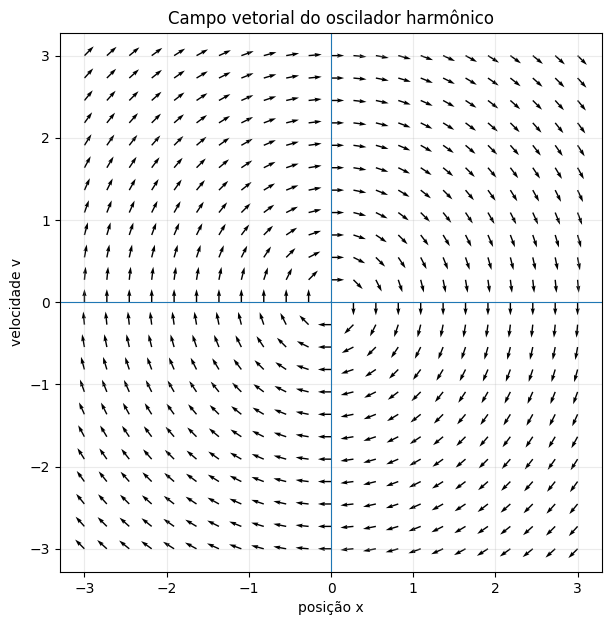

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

omega = 1.0
g = np.linspace(-3, 3, 23)
X, V = np.meshgrid(g, g)

U = V
W = -(omega**2)*X

N = np.sqrt(U**2 + W**2)
N[N == 0] = 1

plt.figure(figsize=(7,7))
plt.quiver(X, V, U/N, W/N)
plt.axhline(0, linewidth=.8)
plt.axvline(0, linewidth=.8)
plt.xlabel("posição x")
plt.ylabel("velocidade v")
plt.title("Campo vetorial do oscilador harmônico")
plt.axis("equal")
plt.grid(alpha=.25)
plt.show()

## 3. Trajetória e retrato de fase

Uma solução

$$
t\longmapsto (x(t),v(t))
$$

determina uma curva no plano $(x,v)$.

Essa curva orientada pelo sentido crescente do tempo é uma **trajetória**.

O conjunto das trajetórias relevantes constitui o **retrato de fase**.

É essencial distinguir:

- **gráfico temporal:** $t$ aparece em um dos eixos;
- **plano de fase:** os eixos representam variáveis de estado.

No plano de fase, o tempo está presente apenas como **parametrização e orientação** da trajetória.

## 4. Podemos descobrir as trajetórias sem resolver o sistema?

Para o oscilador,

$$
x'=v,\qquad v'=-\omega^2x.
$$

Considere

$$
E(x,v)=\omega^2x^2+v^2.
$$

Ao longo de uma solução,

$$
\frac{dE}{dt}
=
2\omega^2xx'+2vv'.
$$

Substituindo as equações,

$$
\frac{dE}{dt}
=
2\omega^2xv+2v(-\omega^2x)=0.
$$

Portanto,

$$
\boxed{\omega^2x^2+v^2=C.}
$$

As trajetórias não triviais são elipses.

No problema mecânico,

$$
\frac{m}{2}v^2+\frac{k}{2}x^2
$$

é a energia total. Como $k=m\omega^2$, a equação das elipses é precisamente uma expressão da **conservação da energia**.

A ex,istência de uma constante de movimento, no caso a energia, nos permitiu
> entender a geometria das trajetórias sem encontrar explicitamente $x(t)$ e $v(t)$.

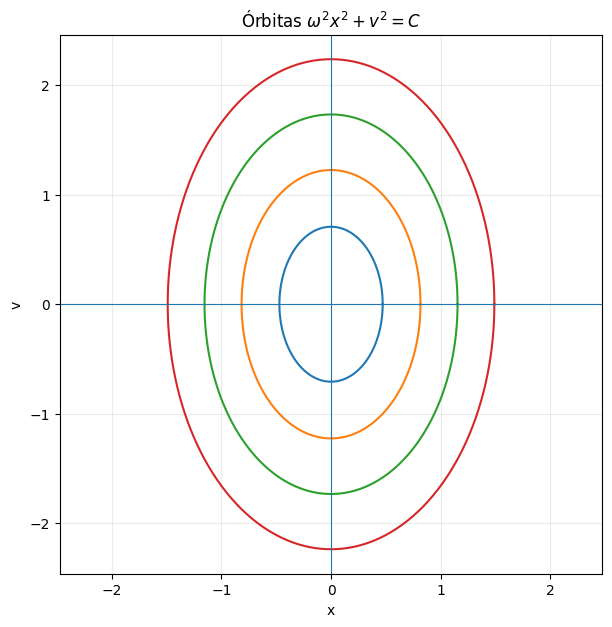

In [ ]:
theta = np.linspace(0, 2*np.pi, 500)
omega = 1.5

plt.figure(figsize=(7,7))
for C in [0.5, 1.5, 3.0, 5.0]:
    x = np.sqrt(C)/omega*np.cos(theta)
    v = np.sqrt(C)*np.sin(theta)
    plt.plot(x, v)

plt.axhline(0, linewidth=.8)
plt.axvline(0, linewidth=.8)
plt.xlabel("x")
plt.ylabel("v")
plt.title(r"Órbitas $\omega^2x^2+v^2=C$")
plt.axis("equal")
plt.grid(alpha=.25)
plt.show()

## 5. Equilíbrio

Para um sistema autônomo

$$
\mathbf{x}'=\mathbf{F}(\mathbf{x}),
$$

um ponto $\mathbf{x}^*$ é um **equilíbrio** quando

$$
\mathbf{F}(\mathbf{x}^*)=0.
$$

Nesse caso,

$$
\mathbf{x}(t)\equiv\mathbf{x}^*
$$

é uma solução constante.

Para o oscilador,

$$
(v,-\omega^2x)=(0,0)
$$

somente quando

$$
(x,v)=(0,0).
$$

Fisicamente, a origem corresponde à massa parada na posição de equilíbrio.

# Parte II — Sistemas lineares

## 6. Definição

Um sistema linear homogêneo planar autônomo tem a forma

$$
\boxed{
\mathbf{x}'=A\mathbf{x},
}
$$

onde

$$
A=
\begin{pmatrix}
a&b\\
c&d
\end{pmatrix},
\qquad
\mathbf{x}=
\begin{pmatrix}
x\\y
\end{pmatrix}.
$$

Em componentes,

$$
\boxed{
\begin{cases}
x'=ax+by,\\
y'=cx+dy.
\end{cases}}
$$

A origem é sempre um equilíbrio, pois

$$
A0=0.
$$

Nesta aula nos concentraremos em matrizes constantes. Mais tarde, consideraremos o caso
$$
\mathbf{x}'=A(t)\mathbf{x}.
$$
De particular interesse será o caso em que $A(t) = A(t+T)$, isto é , quando $A(t)$ for periódico.

## 7. Princípio da superposição

Suponha que $\mathbf{x}_1$ e $\mathbf{x}_2$ sejam soluções de

$$
\mathbf{x}'=A\mathbf{x}.
$$

Então, para quaisquer constantes $c_1,c_2$,

$$
\mathbf{x}=c_1\mathbf{x}_1+c_2\mathbf{x}_2
$$

também é solução.

De fato,

$$
\begin{aligned}
\mathbf{x}'
&=c_1\mathbf{x}_1'+c_2\mathbf{x}_2'\\
&=c_1A\mathbf{x}_1+c_2A\mathbf{x}_2\\
&=A(c_1\mathbf{x}_1+c_2\mathbf{x}_2)\\
&=A\mathbf{x}.
\end{aligned}
$$

Portanto, o conjunto das soluções é um **espaço vetorial**.

Isso é muito mais do que uma propriedade conveniente: permitirá construir todas as soluções a partir de um conjunto pequeno de soluções independentes.

# Parte III — Existência e unicidade no caso linear

## 7A. Norma de uma matriz

Para o sistema linear

$$ \mathbf{x}'=A\mathbf{x}, $$

a matriz $A$ transforma o vetor de estado $\mathbf{x}$ no vetor

$$ A\mathbf{x}. $$

Em breve precisaremos estimar expressões como

$$ \|A\mathbf{x}\|. $$

Isso levanta uma pergunta natural:

Se conhecemos o tamanho de $\mathbf{x}$, quão grande pode ser $A\mathbf{x}$?

Queremos encontrar uma constante $C$ tal que

$$ \|A\mathbf{x}\|\leq C\|\mathbf{x}\| $$

para todo vetor $\mathbf{x}$.

A melhor constante possível para essa desigualdade conduz naturalmente ao conceito de norma de uma matriz.

### Resumo

Uma norma vetorial é uma função

$$ \|\cdot\|:\mathbb R^n\longrightarrow [0,\infty) $$

que associa a cada vetor um número que representa seu tamanho.

Ela satisfaz, para quaisquer $\mathbf{x},\mathbf{y}\in\mathbb R^n$ e $\alpha\in\mathbb R$,

$$ \|\mathbf{x}\|\geq0, $$ $$ \|\mathbf{x}\|=0 \quad\Longleftrightarrow\quad \mathbf{x}=0, $$ $$ \|\alpha\mathbf{x}\|=|\alpha|\,\|\mathbf{x}\|, $$

e

$$ \|\mathbf{x}+\mathbf{y}\| \leq \|\mathbf{x}\|+\|\mathbf{y}\|. $$

Em $\mathbb R^n$, três normas particularmente importantes são

$$ \|\mathbf{x}\|_1=\sum_{i=1}^n|x_i|, $$ $$ \|\mathbf{x}\|_2= \left(\sum_{i=1}^n|x_i|^2\right)^{1/2}, $$

e

$$ \| \mathbf{x} \|_{\infty} = \max_{1 \le i \le n}|x_i| $$

### Um exemplo: diferentes maneiras de medir o mesmo vetor

Considere

$$ \mathbf{x} = \begin{pmatrix} 3\\ -4 \end{pmatrix}. $$

Utilizando a norma $1$,

$$ \|\mathbf{x}\|_1 = |3|+|-4| = 7. $$

Utilizando a norma euclidiana,

$$ \|\mathbf{x}\|_2 = \sqrt{3^2+(-4)^2} = 5. $$

E utilizando a norma infinito,

$$ \|\mathbf{x}\|_\infty = \max\{|3|,|-4|\} = 4. $$

Portanto,

$$ \|\mathbf{x}\|_1=7, \qquad \|\mathbf{x}\|_2=5, \qquad \|\mathbf{x}\|_\infty=4. $$

O mesmo vetor possui diferentes valores de norma.

Isso não é uma contradição. Uma norma não representa um "tamanho absoluto" do vetor; ela estabelece uma determinada maneira de medir seu tamanho.

Em dimensão finita, essas diferentes normas são equivalentes no sentido de que determinam a mesma noção de convergência. Entretanto, os valores numéricos das normas podem ser diferentes.

### Como medir uma matriz?

Uma matriz

$$ A\in\mathbb R^{n\times n} $$

pode ser vista como uma transformação linear

$$ \mathbf{x}\longmapsto A\mathbf{x}. $$

Portanto, em vez de tentar medir diretamente os elementos da matriz, podemos fazer uma pergunta que será particularmente útil para EDOs:

Quanto a transformação $A$ pode aumentar o tamanho de um vetor?

Para um vetor não nulo $\mathbf{x}$, considere a razão

$$ \frac{\|A\mathbf{x}\|}{\|\mathbf{x}\|}. $$

O numerador mede o tamanho do vetor depois da aplicação de $A$ e o denominador mede seu tamanho antes da aplicação de $A$.

Portanto,

$$ \frac{\|A\mathbf{x}\|}{\|\mathbf{x}\|} $$

é o fator de amplificação produzido por $A$ na direção de $\mathbf{x}$.

Esse fator depende, em geral, da direção escolhida.


Isso motiva a seguinte definição.

Definição — Norma matricial induzida

Fixada uma norma em $\mathbb R^n$, definimos a norma de $A$ induzida por essa norma vetorial por

$$ \boxed{ \|A\| = \sup_{\mathbf{x}\neq0} \frac{\|A\mathbf{x}\|}{\|\mathbf{x}\|}. } $$

Essa norma também é chamada de norma matricial natural.

*É importante observar que a norma da matriz depende da
 norma utilizada no espaço de vetores.*

Assim, quando for necessário explicitar essa escolha, escreveremos

$$ \|A\|_1,\qquad \|A\|_2,\qquad \|A\|_\infty. $$

Cada uma delas é induzida pela norma vetorial correspondente.

A definição

$$ \|A\| = \sup_{\mathbf{x}\neq0} \frac{\|A\mathbf{x}\|}{\|\mathbf{x}\|} $$

possui uma forma equivalente muito importante.

Dado $\mathbf{x}\neq0$, defina

$$ \mathbf{u} = \frac{\mathbf{x}}{\|\mathbf{x}\|}. $$

Então

$$ \|\mathbf{u}\|=1. $$

Além disso,

$$ A\mathbf{u} = A\left( \frac{\mathbf{x}}{\|\mathbf{x}\|} \right) = \frac{A\mathbf{x}}{\|\mathbf{x}\|}. $$

Consequentemente,

$$ \|A\mathbf{u}\| = \frac{\|A\mathbf{x}\|}{\|\mathbf{x}\|}. $$

Portanto,

$$ \boxed{ \|A\| = \sup_{\|\mathbf{u}\|=1} \|A\mathbf{u}\|. } $$

Essa segunda expressão fornece uma interpretação geométrica muito clara:

Tomamos todos os vetores da esfera unitária

$$ \|\mathbf{u}\|=1, $$

aplicamos a transformação $A$ e observamos os vetores resultantes

$$ A\mathbf{u}. $$

A norma $\|A\|$ é o maior tamanho que pode ser obtido.

Em outras palavras,

$$ \boxed{ \|A\| = \text{máxima amplificação produzida pela transformação }A. } $$

Essa interpretação será especialmente transparente quando utilizarmos a norma euclidiana.

### Uma desigualdade fundamental

Da definição,

$$ \|A\| = \sup_{\mathbf{x}\neq0} \frac{\|A\mathbf{x}\|}{\|\mathbf{x}\|}. $$

Portanto, para qualquer $\mathbf{x}\neq0$,

$$ \frac{\|A\mathbf{x}\|}{\|\mathbf{x}\|} \leq \|A\|. $$

Multiplicando ambos os lados por $|\mathbf{x}|$, obtemos

$$ \boxed{ \|A\mathbf{x}\| \leq \|A\|\,\|\mathbf{x}\|. } $$

Para $\mathbf{x}=0$, a desigualdade também é trivialmente verdadeira.

Assim,

$$ \boxed{ \|A\mathbf{x}\| \leq \|A\|\,\|\mathbf{x}\| \qquad \text{para todo }\mathbf{x}\in\mathbb R^n. } $$

Essa é a propriedade mais importante da norma matricial para o que faremos nesta disciplina. Ela afirma que, independentemente da direção de $\mathbf{x}$, a transformação $A$ não pode aumentar sua norma por um fator superior a $\|A\|$.

### Um  exemplo

Considere a matriz

$$ A= \begin{pmatrix} 2&0\\ 0&\frac12 \end{pmatrix}. $$

Ela define a transformação

$$ \begin{pmatrix} x\\y \end{pmatrix} \longmapsto \begin{pmatrix} 2x\\ \frac12y \end{pmatrix}. $$

Vamos calcular sua norma induzida pela norma euclidiana.

Para

$$ \mathbf{x} = \begin{pmatrix} x\\y \end{pmatrix}, $$

temos

$$ A\mathbf{x} = \begin{pmatrix} 2x\\ \frac12y \end{pmatrix}. $$

Portanto,

$$ \|A\mathbf{x}\|_2^2 = 4x^2+\frac14y^2. $$

Por outro lado,

$$ \|\mathbf{x}\|_2^2=x^2+y^2. $$

Como

$$ 4x^2+\frac14y^2 \leq 4x^2+4y^2 = 4(x^2+y^2), $$

segue que

$$ \|A\mathbf{x}\|_2^2 \leq 4\|\mathbf{x}\|_2^2. $$

Logo,

$$ \|A\mathbf{x}\|_2 \leq 2\|\mathbf{x}\|_2. $$

Isso mostra que

$$ \|A\|_2\leq2. $$

Mas ainda precisamos verificar se $2$ é realmente a menor constante possível.

Escolha

$$ \mathbf{x} = \begin{pmatrix} 1\\0 \end{pmatrix}. $$

Nesse caso,

$$ \|\mathbf{x}\|_2=1 $$

e

$$ A\mathbf{x} = \begin{pmatrix} 2\\0 \end{pmatrix}, $$

de modo que

$$ \|A\mathbf{x}\|_2=2. $$

Portanto,

$$ \frac{\|A\mathbf{x}\|_2}{\|\mathbf{x}\|_2}=2. $$

Consequentemente,

$$ \boxed{\|A\|_2=2.} $$

Esse exemplo ilustra uma ideia importante: para determinar uma norma induzida, não basta encontrar uma estimativa superior. Precisamos também saber que essa estimativa é a melhor possível.

7A.8 Interpretação geométrica do exemplo

A transformação

$$ A= \begin{pmatrix} 2&0\\ 0&\frac12 \end{pmatrix} $$

age de maneira diferente em diferentes direções.

Na direção

$$ \mathbf{e}_1= \begin{pmatrix} 1\\0 \end{pmatrix}, $$

temos

$$ A\mathbf{e}_1 = 2\mathbf{e}_1. $$

Portanto, os comprimentos são multiplicados por $2$.

Já na direção

$$ \mathbf{e}_2= \begin{pmatrix} 0\\1 \end{pmatrix}, $$

temos

$$ A\mathbf{e}_2 = \frac12\mathbf{e}_2. $$

Os comprimentos são multiplicados por $1/2$.

Se considerarmos todos os vetores da circunferência unitária

$$ x^2+y^2=1, $$

a transformação $A$ leva essa circunferência em uma elipse cujos semieixos possuem comprimentos

$$ 2 \qquad\text{e}\qquad \frac12. $$

O maior desses comprimentos é precisamente

$$ \|A\|_2=2. $$

Essa interpretação será útil mais adiante: a norma euclidiana induzida procura a direção na qual a transformação linear produz a maior dilatação.

### A norma induzida pela norma infinito

Considere agora a norma vetorial

$$ \|\mathbf{x}\|_\infty = \max_{1\leq j\leq n}|x_j|. $$

A norma matricial correspondente é, por definição,

$$ \|A\|_\infty = \sup_{\mathbf{x}\neq0} \frac{\|A\mathbf{x}\|_\infty} {\|\mathbf{x}\|_\infty}. $$

Existe uma fórmula particularmente simples para calculá-la:

$$ \boxed{ \|A\|_\infty = \max_{1\leq i\leq n} \sum_{j=1}^n|a_{ij}|. } $$

Ou seja,

$$ \boxed{ \|A\|_\infty = \text{maior soma dos valores absolutos dos elementos de uma linha}. } $$

Vamos demonstrar essa fórmula.

#### Demonstração da fórmula para $|A|_\infty$

Se

$$ A=(a_{ij}) $$

e

$$ \mathbf{x} = (x_1,\ldots,x_n)^T, $$

a $i$-ésima componente de $A\mathbf{x}$ é

$$ (A\mathbf{x})_i = \sum_{j=1}^n a_{ij}x_j. $$

Pela desigualdade triangular,

$$ |(A\mathbf{x})_i| \leq \sum_{j=1}^n|a_{ij}|\,|x_j|. $$

Mas, pela definição da norma infinito,

$$ |x_j|\leq\|\mathbf{x}\|_\infty $$

para todo $j$.

Logo,

$$ |(A\mathbf{x})_i| \leq \left( \sum_{j=1}^n|a_{ij}| \right) \|\mathbf{x}\|_\infty. $$

Agora tomamos o máximo sobre todas as componentes:

$$ \begin{aligned} \|A\mathbf{x}\|_\infty &= \max_i |(A\mathbf{x})_i|\\ &\leq \max_i \left( \sum_{j=1}^n|a_{ij}| \right) \|\mathbf{x}\|_\infty. \end{aligned} $$

Portanto,

$$ \|A\mathbf{x}\|_\infty \leq \left[ \max_i \sum_j|a_{ij}| \right] \|\mathbf{x}\|_\infty. $$

Isso prova que

$$ \|A\|_\infty \leq \max_i\sum_j|a_{ij}|. $$

Mas ainda precisamos mostrar que essa estimativa pode ser atingida.

Escolha uma linha $i_0$ para a qual

$$ \sum_j|a_{i_0j}| $$

seja máxima.

Agora escolha $\mathbf{x}$ de modo que

$$ x_j= \begin{cases} +1, & a_{i_0j}\geq0,\\ -1, & a_{i_0j}<0. \end{cases} $$

Então

$$ \|\mathbf{x}\|_\infty=1. $$

Além disso,

$$ a_{i_0j}x_j=|a_{i_0j}|. $$

Portanto,

$$ (A\mathbf{x})_{i_0} = \sum_j|a_{i_0j}|. $$

Assim,

$$ \|A\mathbf{x}\|_\infty \geq \sum_j|a_{i_0j}|. $$

Isso fornece a desigualdade oposta e, portanto,

$$ \boxed{ \|A\|_\infty = \max_i\sum_j|a_{ij}|. } $$
### Exemplo

Considere

$$ A= \begin{pmatrix} 5&-4\\ -1&7 \end{pmatrix}. $$

Calculamos a soma dos valores absolutos dos elementos de cada linha.

Primeira linha:

$$ |5|+|-4|=9. $$

Segunda linha:

$$ |-1|+|7|=8. $$

Logo,

$$ \boxed{ \|A\|_\infty=9. } $$

Isso significa que, para todo vetor $\mathbf{x}\in\mathbb R^2$,

$$ \boxed{ \|A\mathbf{x}\|_\infty \leq 9\|\mathbf{x}\|_\infty. } $$

Além disso, o número $9$ não é apenas uma estimativa conveniente: ele é a menor constante possível para a qual essa desigualdade vale para todos os vetores.

#### A norma induzida pela norma $1$

Considere agora

$$ \|\mathbf{x}\|_1 = \sum_{i=1}^n|x_i|. $$

A norma matricial induzida é

$$ \|A\|_1 = \sup_{\mathbf{x}\neq0} \frac{\|A\mathbf{x}\|_1}{\|\mathbf{x}\|_1}. $$

Nesse caso, pode-se demonstrar que

$$ \boxed{ \|A\|_1 = \max_{1\leq j\leq n} \sum_{i=1}^n|a_{ij}|. } $$

Portanto,

A norma $1$ de uma matriz é a maior soma dos valores absolutos dos elementos de uma coluna.

Temos assim uma regra fácil de lembrar:

$$ \boxed{ \begin{aligned} \|A\|_1 &=\text{maior soma absoluta das colunas},\\[2mm] \|A\|_\infty &=\text{maior soma absoluta das linhas}. \end{aligned} } $$
#### Comparando $\|A\|_1$ e $\|A\|_{\infty}$

Retomemos

$$ A= \begin{pmatrix} 5&-4\\ -1&7 \end{pmatrix}. $$

Já calculamos

$$ \|A\|_\infty=9. $$

Para calcular $\|A\|_1$, somamos agora os valores absolutos por coluna.

Primeira coluna:

$$ |5|+|-1|=6. $$

Segunda coluna:

$$ |-4|+|7|=11. $$

Logo,

$$ \boxed{ \|A\|_1=11. } $$

Portanto,

$$ \boxed{ \|A\|_1=11, \qquad \|A\|_\infty=9. } $$



O que permanece essencial é que, para a norma induzida correspondente,

$$ \boxed{ \|A\mathbf{x}\| \leq \|A\|\|\mathbf{x}\|. } $$

## 8. Conexão com Picard–Lindelöf

Considere o PVI

$$
\begin{cases}
\mathbf{x}'=A\mathbf{x},\\
\mathbf{x}(t_0)=\mathbf{x}_0.
\end{cases}
$$

Aqui,

$$
\mathbf{F}(\mathbf{x})=A\mathbf{x}.
$$

Para quaisquer $\mathbf{x},\mathbf{y}$,

$$
\|\mathbf{F}(\mathbf{x})-\mathbf{F}(\mathbf{y})\|
=
\|A(\mathbf{x}-\mathbf{y})\|.
$$

Pela definição da norma matricial induzida,

$$
\|A(\mathbf{x}-\mathbf{y})\|
\leq
\|A\|\,\|\mathbf{x}-\mathbf{y}\|.
$$

Logo $\mathbf F$ é globalmente Lipschitz, com constante

$$
L=\|A\|.
$$

Assim, Picard–Lindelöf garante unicidade local.

No caso linear com coeficientes constantes, porém, podemos dizer mais: a solução existe para **todo** $t\in\mathbb R$.

## 9. Formulação integral

O PVI

$$
\mathbf{x}'=A\mathbf{x},
\qquad
\mathbf{x}(0)=\mathbf{x}_0
$$

é equivalente a

$$
\boxed{
\mathbf{x}(t)
=
\mathbf{x}_0+\int_0^t A\mathbf{x}(s)\,ds.
}
$$

Isso deve lembrar imediatamente as aproximações sucessivas de Picard.

Comecemos com

$$
\mathbf{x}_0(t)=\mathbf{x}_0
$$

e definamos

$$
\mathbf{x}_{n+1}(t)
=
\mathbf{x}_0+
\int_0^t A\mathbf{x}_n(s)\,ds.
$$

Vamos calcular as primeiras aproximações.

## 10. Picard produz a exponencial matricial

Primeira aproximação:

$$
\mathbf{x}_1(t)
=
\mathbf{x}_0+tA\mathbf{x}_0.
$$

Segunda:

$$
\begin{aligned}
\mathbf{x}_2(t)
&=
\mathbf{x}_0+
\int_0^t
A(\mathbf{x}_0+sA\mathbf{x}_0)\,ds\\
&=
\left(
I+tA+\frac{t^2}{2!}A^2
\right)\mathbf{x}_0.
\end{aligned}
$$

Continuando,

$$
\boxed{
\mathbf{x}_n(t)
=
\left(
I+tA+\frac{t^2}{2!}A^2+\cdots+
\frac{t^n}{n!}A^n
\right)\mathbf{x}_0.
}
$$

Isso sugere definir

$$
\boxed{
e^{At}
=
\sum_{k=0}^{\infty}
\frac{t^k}{k!}A^k.
}
$$

Portanto,

$$
\boxed{
\mathbf{x}(t)=e^{At}\mathbf{x}_0.
}
$$

surge naturalmente da **iteração de Picard** aplicada ao sistema linear.

### 10.1 Por que a série converge?

Usando uma norma matricial submultiplicativa,

$$
\|A^k\|\leq \|A\|^k.
$$

Logo,

$$
\left\|
\frac{t^k}{k!}A^k
\right\|
\leq
\frac{|t|^k\|A\|^k}{k!}.
$$

Mas

$$
\sum_{k=0}^{\infty}
\frac{(|t|\|A\|)^k}{k!}
=
e^{|t|\|A\|}
$$

converge.

Em qualquer intervalo limitado de $t$, o mesmo argumento fornece convergência uniforme.


## 11. Verificação da solução

Da série,

$$
e^{At}
=
I+tA+\frac{t^2}{2!}A^2+\cdots.
$$

Derivando termo a termo,

$$
\begin{aligned}
\frac{d}{dt}e^{At}
&=
A+tA^2+\frac{t^2}{2!}A^3+\cdots\\
&=
A
\left(
I+tA+\frac{t^2}{2!}A^2+\cdots
\right).
\end{aligned}
$$

Assim,

$$
\boxed{
\frac{d}{dt}e^{At}=Ae^{At}.
}
$$

Além disso,

$$
e^{A0}=I.
$$

Portanto,

$$
\mathbf{x}(t)=e^{At}\mathbf{x}_0
$$

satisfaz

$$
\mathbf{x}'=A\mathbf{x},
\qquad
\mathbf{x}(0)=\mathbf{x}_0.
$$

Pela unicidade, essa é **a** solução do PVI.

## 12. Algumas propriedades fundamentais de $e^{At}$

Para uma matriz constante $A$,

$$
e^{A0}=I,
$$

$$
e^{A(t+s)}=e^{At}e^{As},
$$

e

$$
(e^{At})^{-1}=e^{-At}.
$$

Portanto, para dados em $t=\tau$,

$$
\boxed{
\mathbf{x}(t)=e^{A(t-\tau)}\mathbf{x}(\tau).
}
$$

A matriz  $e^{A(t-\tau)}$ é a **matriz de transição** do sistema autônomo.

Ela transporta o estado no instante $\tau$ para o estado no instante $t$.

## 13. Um ponto técnico importante: $e^{P+Q}$

Para números,

$$
e^{p+q}=e^pe^q.
$$

Para matrizes, isso **não é verdade em geral**.

Se

$$
PQ=QP,
$$

então

$$
\boxed{e^{P+Q}=e^Pe^Q.}
$$

A condição de comutatividade é essencial.

Essa é uma das primeiras diferenças importantes entre exponenciais escalares e matriciais.

# Parte IV — Antes dos autovalores: um sistema desacoplado

## 14. Exemplo paramétrico

Considere

$$
\boxed{
\begin{cases}
x'=ax,\\
y'=-y.
\end{cases}}
$$

As equações estão desacopladas:

$$
x(t)=x_0e^{at},
\qquad
y(t)=y_0e^{-t}.
$$

A matriz é

$$
A=
\begin{pmatrix}
a&0\\
0&-1
\end{pmatrix}.
$$

O comportamento muda qualitativamente quando variamos $a$.

Vamos primeiro prever:

- o que acontece quando $a<0$?
- quando $a=0$?
- quando $a>0$?
- dentro de $a<0$, faz diferença comparar $a$ com $-1$?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def retrato_diagonal(a):
    def F(t,z):
        x,y=z
        return [a*x,-y]

    g=np.linspace(-2.5,2.5,21)
    X,Y=np.meshgrid(g,g)
    U=a*X
    V=-Y
    N=np.sqrt(U**2+V**2)
    N[N==0]=1

    plt.figure(figsize=(6.5,6.5))
    plt.quiver(X,Y,U/N,V/N)

    iniciais=[(2,2),(2,1),(1,2),(-2,2),(-2,-1),
              (2,-2),(1,-2),(-1,-2)]
    for z0 in iniciais:
        sol=solve_ivp(F,[0,4],z0,max_step=.03)
        plt.plot(sol.y[0],sol.y[1])
        sol=solve_ivp(F,[0,-3],z0,max_step=.03)
        plt.plot(sol.y[0],sol.y[1])

    plt.axhline(0,linewidth=.8)
    plt.axvline(0,linewidth=.8)
    plt.xlim(-2.5,2.5); plt.ylim(-2.5,2.5)
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(f"x'={a}x,  y'=-y")
    plt.grid(alpha=.2)
    plt.show()

# Experimente: -2, -0.5, 0, 0.5, 2
retrato_diagonal(-2)

## 15. O que o exemplo anterior nos ensina?

Os eixos coordenados são especiais.

Se $y(0)=0$, então

$$
y(t)=0
$$

para todo $t$, e a trajetória permanece no eixo $x$.

Se $x(0)=0$, então

$$
x(t)=0
$$

para todo $t$, e a trajetória permanece no eixo $y$.

Esses eixos são **retas invariantes**.

Mas isso ocorreu porque a matriz era diagonal. Para uma matriz geral, as direções invariantes podem estar inclinadas.

Surge então a pergunta fundamental:

> **Como encontrar uma reta pela origem que seja preservada pelo fluxo?**

# Parte V — De uma pergunta geométrica aos autovetores

## 16. Retas invariantes

Considere

$$
\mathbf{x}'=A\mathbf{x}.
$$

Suponha que uma trajetória permaneça sobre a reta gerada por um vetor não nulo $v$.

Então podemos escrevê-la como

$$
\mathbf{x}(t)=u(t)v.
$$

Derivando,

$$
\mathbf{x}'(t)=u'(t)v.
$$

Mas a equação diferencial exige

$$
\mathbf{x}'(t)=A\mathbf{x}(t)=u(t)Av.
$$

Logo,

$$
u'(t)v=u(t)Av.
$$

Para que o lado direito permaneça na direção de $v$, precisamos que

$$
\boxed{Av=\lambda v}
$$

para algum escalar $\lambda$.

Assim, **autovetores surgem como as direções invariantes do sistema**.

## 17. A dinâmica ao longo de uma autodireção

Se

$$
Av=\lambda v
$$

e

$$
\mathbf{x}(t)=u(t)v,
$$

então

$$
u'(t)v=\lambda u(t)v.
$$

Como $v\neq0$,

$$
u'=\lambda u.
$$

Essa é uma EDO escalar já conhecida:

$$
u(t)=Ce^{\lambda t}.
$$

Portanto,

$$
\boxed{
\mathbf{x}(t)=Ce^{\lambda t}v.
}
$$

Temos uma interpretação extremamente importante:

- $v$ determina **a direção geométrica**;
- $\lambda$ determina **a evolução temporal nessa direção**.

Se $\lambda<0$, a solução decai ao longo da reta.

Se $\lambda>0$, cresce ao longo da reta.

Se $\lambda=0$, os pontos dessa direção são equilíbrios.

## 18. A mesma conclusão pela exponencial matricial

Se $Av=\lambda v$, então

$$
A^2v=\lambda^2v,\qquad
A^3v=\lambda^3v,
$$

e, em geral,

$$
A^kv=\lambda^kv.
$$

Logo,

$$
\begin{aligned}
e^{At}v
&=
\left(
I+tA+\frac{t^2}{2!}A^2+\cdots
\right)v\\
&=
\left(
1+\lambda t+\frac{\lambda^2t^2}{2!}+\cdots
\right)v\\
&=
e^{\lambda t}v.
\end{aligned}
$$

Portanto,

$$
\boxed{e^{At}v=e^{\lambda t}v.}
$$

A abordagem geométrica de autovetores e a abordagem analítica pela exponencial matricial chegam exatamente ao mesmo resultado.

# Parte VI — Dois autovetores independentes

## 19. Construção da solução geral

Suponha que $A$ tenha dois autovetores linearmente independentes

$$
v_1,\qquad v_2,
$$

associados a autovalores

$$
\lambda_1,\qquad\lambda_2.
$$

Temos duas soluções:

$$
\mathbf{x}_1(t)=e^{\lambda_1t}v_1,
$$

$$
\mathbf{x}_2(t)=e^{\lambda_2t}v_2.
$$

Pela superposição,

$$
\boxed{
\mathbf{x}(t)
=
c_1e^{\lambda_1t}v_1
+
c_2e^{\lambda_2t}v_2.
}
$$

Por que isso fornece **todas** as soluções?

Como $v_1,v_2$ formam uma base de $\mathbb R^2$, qualquer condição inicial pode ser escrita como

$$
\mathbf{x}_0=c_1v_1+c_2v_2.
$$

A expressão acima é uma solução que satisfaz essa condição inicial. Pela **unicidade** do PVI, nenhuma outra solução pode existir com o mesmo dado inicial.

Aqui aparece novamente Picard–Lindelöf, agora desempenhando um papel estrutural na teoria linear.

## 20. O espaço de soluções

O raciocínio anterior é um caso particular de um fato mais geral.

Para um sistema homogêneo linear em $\mathbb R^n$,

$$
\mathbf{x}'=A(t)\mathbf{x},
$$

o conjunto das soluções é um espaço vetorial de dimensão $n$.

Escolhendo uma base $b_1,\ldots,b_n$ do espaço de estados e resolvendo os PVIs correspondentes, obtemos $n$ soluções linearmente independentes.

Uma coleção de $n$ soluções linearmente independentes é chamada de **sistema fundamental de soluções**.

Colocando essas soluções como colunas,

$$
\Psi(t)=
\begin{pmatrix}
|&&|\\
\psi_1(t)&\cdots&\psi_n(t)\\
|&&|
\end{pmatrix},
$$

obtemos uma **matriz fundamental**.

No caso autônomo constante, uma escolha canônica é

$$
\boxed{\Psi(t)=e^{At}.}
$$

# Parte VII — Um exemplo completo

## 21. Exemplo: resolver e interpretar

Considere

$$
\boxed{
\begin{cases}
x'=x+y,\\
y'=4x-2y,
\end{cases}}
$$

com

$$
(x(0),y(0))=(2,-3).
$$

A matriz é

$$
A=
\begin{pmatrix}
1&1\\
4&-2
\end{pmatrix}.
$$

O polinômio característico é

$$
\det(A-\lambda I)
=
\begin{vmatrix}
1-\lambda&1\\
4&-2-\lambda
\end{vmatrix}.
$$

Portanto,

$$
(1-\lambda)(-2-\lambda)-4=0,
$$

isto é,

$$
\lambda^2+\lambda-6=0.
$$

Assim,

$$
\boxed{\lambda_1=2,\qquad\lambda_2=-3.}
$$

## 22. Autovetores

Para $\lambda_1=2$,

$$
(A-2I)v=0,
$$

e podemos escolher

$$
v_1=
\begin{pmatrix}
1\\1
\end{pmatrix}.
$$

Para $\lambda_2=-3$,

$$
(A+3I)v=0,
$$

e podemos escolher

$$
v_2=
\begin{pmatrix}
1\\-4
\end{pmatrix}.
$$

Logo,

$$
\mathbf{x}(t)
=
c_1e^{2t}
\begin{pmatrix}1\\1\end{pmatrix}
+
c_2e^{-3t}
\begin{pmatrix}1\\-4\end{pmatrix}.
$$

Aplicando

$$
\mathbf{x}(0)=
\begin{pmatrix}2\\-3\end{pmatrix},
$$

obtemos

$$
\begin{pmatrix}2\\-3\end{pmatrix}
=
c_1
\begin{pmatrix}1\\1\end{pmatrix}
+
c_2
\begin{pmatrix}1\\-4\end{pmatrix}.
$$

Daí,

$$
c_1=c_2=1.
$$

Portanto,

$$
\boxed{
x(t)=e^{2t}+e^{-3t},
}
$$

$$
\boxed{
y(t)=e^{2t}-4e^{-3t}.
}
$$

## 23. Antes do gráfico: o que já sabemos?

A solução contém duas componentes:

$$
e^{2t}v_1
\qquad\text{e}\qquad
e^{-3t}v_2.
$$

A direção $v_1=(1,1)$ cresce quando $t\to+\infty$.

A direção $v_2=(1,-4)$ decai quando $t\to+\infty$.

Portanto:

- uma direção conduz as soluções **para longe** da origem;
- outra conduz as soluções **para a origem**.

Sem desenhar nada, já sabemos que a geometria será muito diferente da do oscilador harmônico.

Vamos agora comparar essa previsão com o retrato de fase.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

A=np.array([[1.,1.],[4.,-2.]])

def F(t,z):
    return A@z

g=np.linspace(-4,4,25)
X,Y=np.meshgrid(g,g)
U=X+Y
V=4*X-2*Y
N=np.sqrt(U**2+V**2)
N[N==0]=1

plt.figure(figsize=(7,7))
plt.quiver(X,Y,U/N,V/N)

# autodireções
xx=np.linspace(-4,4,200)
plt.plot(xx, xx, "--", linewidth=1.3, label=r"$v_1=(1,1)$")
plt.plot(xx, -4*xx, "--", linewidth=1.3, label=r"$v_2=(1,-4)$")

for z0 in [(2,-3),(2,0),(0,2),(-2,0),(0,-2),(1,2),(-1,-2)]:
    for T in ([0,1.5],[0,-1.5]):
        sol=solve_ivp(F,T,z0,max_step=.015)
        plt.plot(sol.y[0],sol.y[1])

plt.axhline(0,linewidth=.8)
plt.axvline(0,linewidth=.8)
plt.xlim(-4,4); plt.ylim(-4,4)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Retrato de fase e autodireções")
plt.legend()
plt.grid(alpha=.2)
plt.show()

## 24. Uma consequência geométrica da unicidade

Duas trajetórias distintas podem se cruzar?

Suponha que duas trajetórias passem pelo mesmo ponto $\mathbf{x}_*$ em algum instante. Podemos tomar esse instante como novo tempo inicial.

As duas seriam então soluções do mesmo PVI

$$
\mathbf{x}'=A\mathbf{x},
\qquad
\mathbf{x}(0)=\mathbf{x}_*.
$$

Mas esse PVI possui solução única.

Logo,

$$
\boxed{
\text{trajetórias distintas não podem se interceptar.}
}
$$

O teorema de unicidade tem, portanto, uma consequência diretamente visível no retrato de fase.

# Parte VIII — Matriz de transição e interpretação dinâmica

## 25. O fluxo linear

Para

$$
\mathbf{x}'=A\mathbf{x},
$$

a solução com condição inicial $\mathbf{x}_0$ é

$$
\mathbf{x}(t)=e^{At}\mathbf{x}_0.
$$

Para cada $t$, a matriz

$$
e^{At}
$$

é uma transformação linear do espaço de estados em si mesmo.

Assim, podemos interpretar a dinâmica como uma família de transformações:

$$
\Phi_t(\mathbf{x}_0)=e^{At}\mathbf{x}_0.
$$

Além disso,

$$
\Phi_{t+s}
=
\Phi_t\circ\Phi_s,
$$

pois

$$
e^{A(t+s)}=e^{At}e^{As}.
$$

Essa propriedade expressa matematicamente uma ideia natural:

> evoluir durante $s$ unidades de tempo e depois durante $t$ unidades produz o mesmo estado que evoluir diretamente durante $t+s$.

## 26. Matriz de transição no caso não autônomo

Logemann & Ryan consideram também

$$
\mathbf{x}'=A(t)\mathbf{x}.
$$

Nesse caso, a solução pode ser escrita como

$$
\mathbf{x}(t)=\Phi(t,\tau)\mathbf{x}(\tau),
$$

onde $\Phi(t,\tau)$ é a **matriz de transição**.

Ela satisfaz

$$
\Phi(\tau,\tau)=I,
$$

$$
\Phi(t,\tau)=\Phi(t,s)\Phi(s,\tau),
$$

e

$$
\Phi(t,\tau)^{-1}=\Phi(\tau,t).
$$

Quando $A$ é constante,

$$
\boxed{
\Phi(t,\tau)=e^{A(t-\tau)}.
}
$$

Não desenvolveremos agora toda a teoria de $A(t)$, mas é importante perceber que $e^{At}$ pertence a uma teoria mais geral.

## 27. Uma observação sobre a série de Peano–Baker

No sistema não autônomo,

$$
\mathbf{x}'=A(t)\mathbf{x},
$$

a matriz de transição pode ser construída por iterações sucessivas, produzindo a série

$$
\Phi(t,s)
=
I+
\int_s^t A(\sigma_1)\,d\sigma_1
+
\int_s^t A(\sigma_1)
\int_s^{\sigma_1}A(\sigma_2)\,d\sigma_2\,d\sigma_1
+\cdots.
$$

Essa é a **série de Peano–Baker**.

Se $A(t)\equiv A$ é constante, as integrais iteradas fornecem

$$
\frac{(t-s)^k}{k!}A^k,
$$

e recuperamos

$$
\Phi(t,s)
=
\sum_{k=0}^{\infty}
\frac{(t-s)^k}{k!}A^k
=
e^{A(t-s)}.
$$

Mais uma vez, a exponencial matricial aparece como a versão linear da construção por aproximações sucessivas.

# Parte IX — Investigação geométrica

## 28. Um sistema que ainda não vamos classificar formalmente

Considere

$$
\boxed{
\begin{cases}
x'=-2x+y,\\
y'=x-2y.
\end{cases}}
$$

ou

$$
A=
\begin{pmatrix}
-2&1\\
1&-2
\end{pmatrix}.
$$

Antes de calcular autovalores:

1. determine o equilíbrio;
2. calcule o campo nos pontos $(1,0)$, $(0,1)$, $(1,1)$ e $(1,-1)$;
3. observe numericamente o retrato;
4. procure duas retas invariantes;
5. somente depois calcule os autovetores.

A ordem é proposital:

$$
\boxed{
\text{observar}
\to
\text{conjecturar}
\to
\text{calcular}
\to
\text{explicar}.
}
$$

In [ ]:
A=np.array([[-2.,1.],[1.,-2.]])

def F(t,z):
    return A@z

g=np.linspace(-3,3,23)
X,Y=np.meshgrid(g,g)
U=-2*X+Y
V=X-2*Y
N=np.sqrt(U**2+V**2)
N[N==0]=1

plt.figure(figsize=(7,7))
plt.quiver(X,Y,U/N,V/N)

for z0 in [(2,0),(0,2),(-2,0),(0,-2),
           (2,2),(-2,-2),(2,-2),(-2,2),(2,1),(1,2)]:
    sol=solve_ivp(F,[0,4],z0,max_step=.03)
    plt.plot(sol.y[0],sol.y[1])

xx=np.linspace(-3,3,100)
plt.plot(xx,xx,"--",linewidth=1)
plt.plot(xx,-xx,"--",linewidth=1)

plt.axhline(0,linewidth=.8)
plt.axvline(0,linewidth=.8)
plt.xlim(-3,3); plt.ylim(-3,3)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Procure as direções invariantes")
plt.grid(alpha=.2)
plt.show()

## 29. Resolvendo a investigação

O polinômio característico é

$$
\det(A-\lambda I)
=
(-2-\lambda)^2-1.
$$

Logo,

$$
(-2-\lambda)^2=1,
$$

e

$$
\lambda_1=-1,\qquad
\lambda_2=-3.
$$

Para $\lambda_1=-1$, podemos tomar

$$
v_1=
\begin{pmatrix}1\\1\end{pmatrix}.
$$

Para $\lambda_2=-3$,

$$
v_2=
\begin{pmatrix}1\\-1\end{pmatrix}.
$$

Portanto,

$$
\boxed{
\mathbf{x}(t)
=
c_1e^{-t}
\begin{pmatrix}1\\1\end{pmatrix}
+
c_2e^{-3t}
\begin{pmatrix}1\\-1\end{pmatrix}.
}
$$

Agora podemos explicar o que o gráfico mostrou.

Quando $t\to+\infty$, ambas as componentes decaem, mas

$$
e^{-3t}
$$

decai muito mais rapidamente que

$$
e^{-t}.
$$

Assim, para uma condição inicial genérica,

$$
\mathbf{x}(t)
\sim
c_1e^{-t}v_1.
$$

Consequentemente, as trajetórias aproximam-se da origem tangentes à direção de $v_1$.

Essa diferença entre uma direção **rápida** e uma direção **lenta** será central na próxima aula.

# Parte X — Um primeiro olhar para a teoria espectral

## 30. O que os autovalores estão nos dizendo?

Até agora encontramos soluções

$$
e^{\lambda t}v.
$$

O fator

$$
e^{\lambda t}
$$

controla o crescimento ou decaimento.

Para autovalores reais:

- $\lambda<0$: decaimento exponencial;
- $\lambda>0$: crescimento exponencial;
- $\lambda=0$: ausência de crescimento exponencial nessa direção.

Em dimensão maior — e também quando aparecem autovalores complexos — a ideia correta é observar

$$
\operatorname{Re}\lambda.
$$

Logemann & Ryan formalizam essa ideia mostrando que o crescimento de

$$
\|e^{At}\|
$$

é governado pelo espectro de $A$.

Na próxima aula veremos geometricamente como isso produz nós, selas, centros e espirais.

# Parte XI — Questões conceituais

## 31. Para discutir em sala

1. Por que $(x,v)$ é um estado adequado para o oscilador, mas $x$ sozinho não é?

2. Qual é a diferença entre campo vetorial, trajetória e retrato de fase?

3. No oscilador harmônico, por que uma órbita fechada representa uma solução periódica?

4. Em que sentido a conservação da energia é uma informação geométrica sobre o plano de fase?

5. Por que o conjunto das soluções de $\mathbf{x}'=A\mathbf{x}$ é um espaço vetorial?

6. Onde usamos a linearidade de $A$ na demonstração da superposição?

7. Como Picard–Lindelöf aparece na teoria de sistemas lineares?

8. Por que a série de Picard sugere a definição de $e^{At}$?

9. Por que $Av=\lambda v$ tem uma interpretação dinâmica, e não apenas algébrica?

10. Por que um autovetor determina uma reta invariante?

11. Por que dois autovetores independentes permitem representar qualquer condição inicial em $\mathbb R^2$?

12. Onde a unicidade é usada para concluir que a combinação das duas eigensoluções é a solução geral?

13. Por que duas trajetórias distintas não podem se cruzar?

14. Qual é a interpretação de $e^{At}$ como transformação do espaço de estados?

15. Por que não devemos escrever indiscriminadamente $e^{P+Q}=e^Pe^Q$ para matrizes?

# Parte XII — Exercícios

## Exercício 1 — Da segunda ordem ao plano de fase

Transforme cada equação em um sistema de primeira ordem:

$$
\text{(a)}\quad y''+4y=0,
$$

$$
\text{(b)}\quad y''+2y'+5y=0,
$$

$$
\text{(c)}\quad y''=t-y+(y')^2.
$$

Em cada caso, identifique o vetor de estado e diga se o sistema obtido é autônomo, linear, ambos ou nenhum dos dois.

---

## Exercício 2 — Energia e geometria

Considere

$$
x'=v,\qquad v'=-4x.
$$

1. Mostre que $4x^2+v^2$ é constante ao longo das soluções.
2. Esboce as trajetórias.
3. Determine o sentido do movimento.
4. Interprete fisicamente a constante de movimento.

---

## Exercício 3 — Superposição

Se $\mathbf{x}_1,\mathbf{x}_2$ são soluções de

$$
\mathbf{x}'=A\mathbf{x},
$$

prove diretamente que

$$
c_1\mathbf{x}_1+c_2\mathbf{x}_2
$$

é solução. Explique por que a mesma afirmação não vale, em geral, para um sistema não linear

$$
\mathbf{x}'=\mathbf F(\mathbf{x}).
$$

Dê um contraexemplo simples.

---

## Exercício 4 — Exponencial matricial

Partindo da definição

$$
e^{At}=\sum_{k=0}^{\infty}\frac{t^kA^k}{k!},
$$

mostre formalmente que

$$
\frac{d}{dt}e^{At}=Ae^{At},
$$

e conclua que

$$
\mathbf{x}(t)=e^{At}\mathbf{x}_0
$$

resolve o PVI linear.

---

## Exercício 5 — Autodireções

Considere

$$
A=
\begin{pmatrix}
3&1\\
1&3
\end{pmatrix}.
$$

1. Encontre os autovalores e autovetores.
2. Identifique as retas invariantes.
3. Escreva a solução geral.
4. Antes de desenhar, descreva o comportamento quando $t\to+\infty$.
5. Confirme sua previsão numericamente.

---

## Exercício 6 — Unicidade e plano de fase

Considere $\mathbf{x}'=A\mathbf{x}$. Demonstre, usando o teorema de unicidade, que duas trajetórias distintas não podem se cruzar.

Explique cuidadosamente por que simplesmente dizer que “o campo tem uma única seta em cada ponto” não constitui, sozinho, uma demonstração de unicidade.

---

## Exercício 7 — Direções rápida e lenta

Para

$$
A=
\begin{pmatrix}
-3&2\\
2&-3
\end{pmatrix},
$$

encontre os autovalores e autovetores e determine qual direção domina o comportamento das soluções genéricas quando $t\to+\infty$.

Justifique analiticamente.

---

## Exercício 8 — Matriz diagonal

Se

$$
A=
\begin{pmatrix}
\lambda_1&0\\
0&\lambda_2
\end{pmatrix},
$$

calcule $e^{At}$ diretamente pela série e verifique que

$$
e^{At}
=
\begin{pmatrix}
e^{\lambda_1t}&0\\
0&e^{\lambda_2t}
\end{pmatrix}.
$$

---

## Exercício 9 — Comutatividade

Escolha duas matrizes $2\times2$ que não comutem e verifique, por cálculo, que em geral

$$
e^{P+Q}\neq e^Pe^Q.
$$

---

## Exercício 10 — Investigação

Considere

$$
\begin{cases}
x'=4x-y,\\
y'=2x+y.
\end{cases}
$$

1. Desenhe numericamente o campo vetorial.
2. Tente identificar visualmente direções invariantes.
3. Calcule os autovalores e autovetores.
4. Escreva a solução geral.
5. Retorne ao gráfico e explique cada característica observada a partir da solução analítica.

# Parte XIII — Síntese da aula

Começamos com uma EDO de segunda ordem e chegamos a uma teoria geométrica e algébrica para

$$
\mathbf{x}'=A\mathbf{x}.
$$

O percurso foi

$$
\boxed{
\text{EDO de ordem superior}
\to
\text{sistema}
\to
\text{plano de fase}
\to
\text{campo vetorial}
\to
\text{Picard}
\to
e^{At}
\to
\text{autovetores}
\to
\text{direções invariantes}.
}
$$

As duas fórmulas centrais foram

$$
\boxed{\mathbf{x}(t)=e^{At}\mathbf{x}_0}
$$

e

$$
\boxed{Av=\lambda v
\quad\Longrightarrow\quad
e^{At}v=e^{\lambda t}v.}
$$

A primeira fornece a solução global do PVI linear.

A segunda transforma informação algébrica sobre $A$ em informação geométrica e dinâmica.

### Próxima aula

Na Aula 11 usaremos essas ferramentas para classificar os retratos de fase:

- autovalores reais de mesmo sinal;
- autovalores reais de sinais opostos;
- direções rápida e lenta;
- autovalores complexos;
- centros e espirais;
- interpretação de $\operatorname{Re}\lambda$ e $\operatorname{Im}\lambda$.

Ou seja, passaremos da pergunta

> **“Como resolvemos $\mathbf{x}'=A\mathbf{x}$?”**

para

> **“Como podemos prever a geometria de todas as soluções olhando para $A$?”**

## Referências utilizadas na construção desta aula

- Steven H. Strogatz, *Nonlinear Dynamics and Chaos*, Capítulo 5: sistemas lineares planares, oscilador harmônico, plano de fase, autovetores e interpretação geométrica.
- Hartmut Logemann e Eugene P. Ryan, *Ordinary Differential Equations: Analysis, Qualitative Theory and Control*, Capítulo 2: sistemas lineares homogêneos, matriz de transição, espaço de soluções e sistemas autônomos.

A exposição foi reorganizada para combinar a abordagem qualitativa de Strogatz com a fundamentação técnica de Logemann–Ryan.